In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
app_name = "mummi"
cp_dir = "/p/lustre2/pandey2/cp_dir"

In [4]:
with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots

def binned_category():
    if app_name == "mummi":
        size_bins = [
        0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
        1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
        268435456, 536870912, 1073741824, float('inf')
        ]
        size_labels = [
        '<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
        '8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
        ]
        degree_bins = [
            0, 2, 3, 4, 5, 6, 10, 20, float('inf')
        ]
        degree_labels = [
            '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
        ]
    
    elif app_name == "montage":
        size_bins = [
        0,128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144
        ]
        size_labels = [
        '<128B','128B-256B','256B-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB'
        ]
        degree_bins = [
            0, 100, 500, 1000, 1500, 2000, 2500, 3000, float('inf')
        ]
        degree_labels = [
            '<100', '100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '>3000',
        ]

    elif app_name == "test":
        size_bins = [
        0,32,64, 128
        ]
        size_labels = [
        '32','64', '128'
        ]
        degree_bins = [
            0, 1, 2, 3, 4
        ]
        degree_labels = [
            '1', '2', '3', '4'
        ]

    elif app_name == "deepspeed1" or app_name=="deepspeed2":
        size_bins = [
        0,128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144
        ]
        size_labels = [
        '<128B','128B-256B','256B-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
        '64-128KB', '128-256KB'
        ]
        degree_bins = [
            0, 2, 3, 4, 5, 6, 10, 20, float('inf')
        ]
        degree_labels = [
            '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
        ]

    return size_bins, size_labels, degree_bins, degree_labels

size_bins, size_labels, degree_bins, degree_labels = binned_category()

/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [5]:
events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)

In [6]:
events_obj.inter.compute()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1,1,8,0.533333
1,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1,1,8,0.8
2,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1,1,8,0.888889
3,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1,1,9,1.0
4,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1,1,69,0.381215
...,...,...,...,...,...,...,...,...,...,...,...,...
18485,read,104999,1048576,11916942177,11916942344,/p/vast1,167,397,1,1,40,0.239521
18486,read,104999,22,11916942601,11916942607,/p/vast1,6,397,1,1,5,0.833333
18487,read,104999,42,11916942723,11916942728,/p/vast1,5,397,1,1,5,1.0
18488,read,104999,250,11916942806,11916942811,/p/vast1,5,397,1,1,5,1.0


In [7]:
events_obj.inter.mount_point.unique().compute()

0    /p/gpfs1
1    /p/vast1
Name: mount_point, dtype: string

In [9]:

plot = GrepIOPlots()



In [12]:
events_obj.inter['size'].max().compute()

np.int64(617099444)

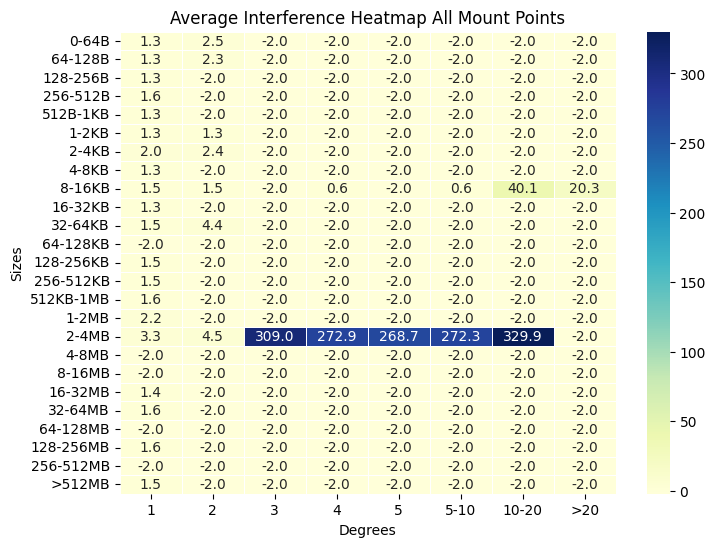

In [13]:
size_bins = [
    0,              # 0 bytes
    64,             # 64 bytes
    128,            # 128 bytes
    256,            # 256 bytes
    512,            # 512 bytes
    1024,           # 1 KB
    2048,           # 2 KB
    4096,           # 4 KB
    8192,           # 8 KB
    16384,          # 16 KB
    32768,          # 32 KB
    65536,          # 64 KB
    131072,         # 128 KB
    262144,         # 256 KB
    524288,         # 512 KB
    1048576,        # 1 MB
    2097152,        # 2 MB
    4194304,        # 4 MB
    8388608,        # 8 MB
    16777216,       # 16 MB
    33554432,       # 32 MB
    67108864,       # 64 MB
    134217728,      # 128 MB
    268435456,      # 256 MB
    536870912,      # 512 MB
    float('inf')    # Infinity
]

size_labels = [
    '0-64B', '64-128B', '128-256B', '256-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB',
    '8-16KB', '16-32KB', '32-64KB', '64-128KB', '128-256KB', '256-512KB', '512KB-1MB',
    '1-2MB', '2-4MB', '4-8MB', '8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB',
    '256-512MB', '>512MB'
]
plot.hmap(df=events_obj.inter.compute(), size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

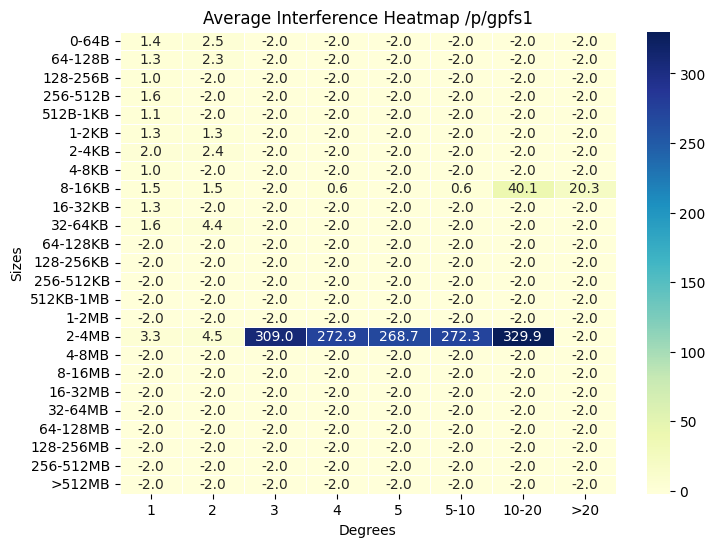

In [14]:
plot.hmap(mp='/p/gpfs1', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

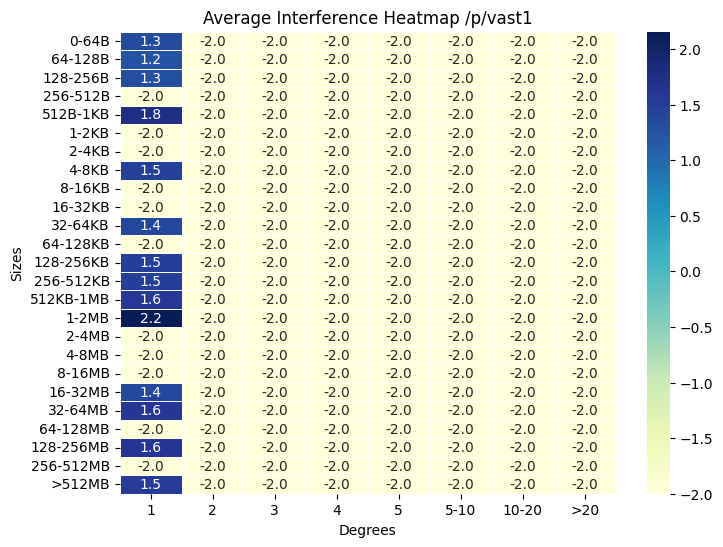

In [15]:
plot.hmap(mp='/p/vast1', df= events_obj.inter.compute(), size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [16]:
read_df = events_obj.inter.query('name == "read"').compute()
read_df

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1,1,8,0.533333
1,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1,1,8,0.8
2,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1,1,8,0.888889
3,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1,1,9,1.0
5,read,104999,8192,332008077,332008092,/p/gpfs1,15,11,1,1,8,0.533333
...,...,...,...,...,...,...,...,...,...,...,...,...
18485,read,104999,1048576,11916942177,11916942344,/p/vast1,167,397,1,1,40,0.239521
18486,read,104999,22,11916942601,11916942607,/p/vast1,6,397,1,1,5,0.833333
18487,read,104999,42,11916942723,11916942728,/p/vast1,5,397,1,1,5,1.0
18488,read,104999,250,11916942806,11916942811,/p/vast1,5,397,1,1,5,1.0


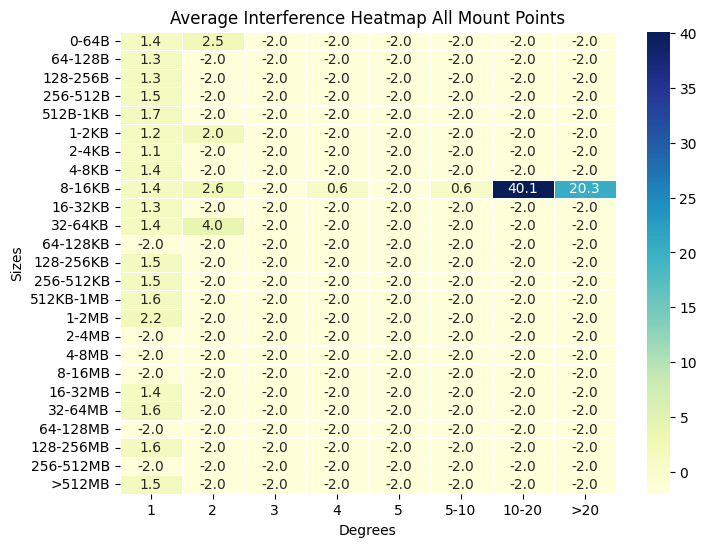

In [17]:
plot.hmap(df= read_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

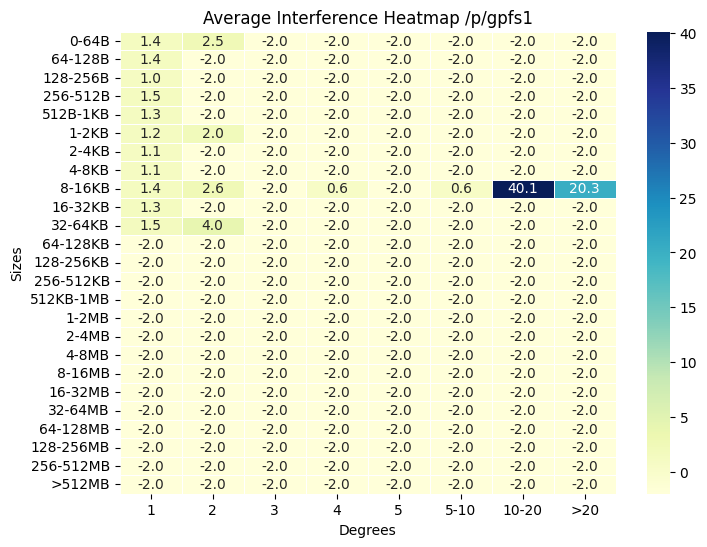

In [18]:
plot.hmap(mp='/p/gpfs1', df= read_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

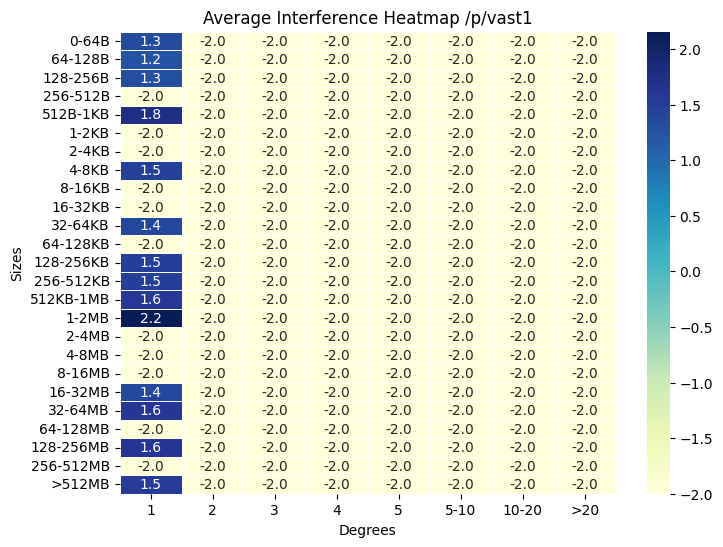

In [19]:
plot.hmap(mp='/p/vast1', df= read_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [20]:
write_df = events_obj.inter.query('name == "write"').compute()
write_df

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
4,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1,1,69,0.381215
25,write,104999,33854,332511787,332512396,/p/gpfs1,609,11,1,1,69,0.1133
26,write,104999,33854,332903442,332903553,/p/gpfs1,111,11,1,1,69,0.621622
47,write,104999,33854,334369942,334370044,/p/gpfs1,102,11,1,1,69,0.676471
48,write,104999,33854,334767682,334767779,/p/gpfs1,97,11,1,1,69,0.71134
...,...,...,...,...,...,...,...,...,...,...,...,...
16920,write,67771,2048,40090103466,40090103486,/p/gpfs1,20,1336,1,1,14,0.7
16921,write,67771,10240,40090111829,40090111849,/p/gpfs1,20,1336,1,1,14,0.7
16922,write,67771,2048,40090120047,40090120067,/p/gpfs1,20,1336,1,1,14,0.7
16923,write,67771,3236864,40090139924,40090205432,/p/gpfs1,65508,1336,1,1,212,0.003236


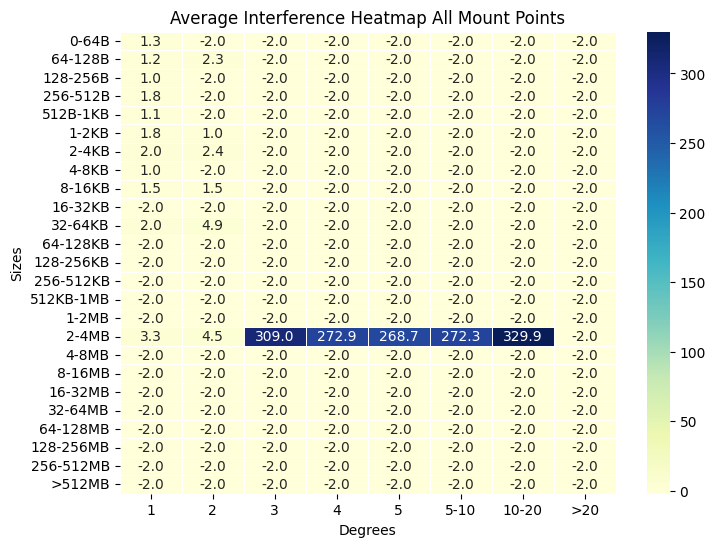

In [23]:
plot.hmap(df= write_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

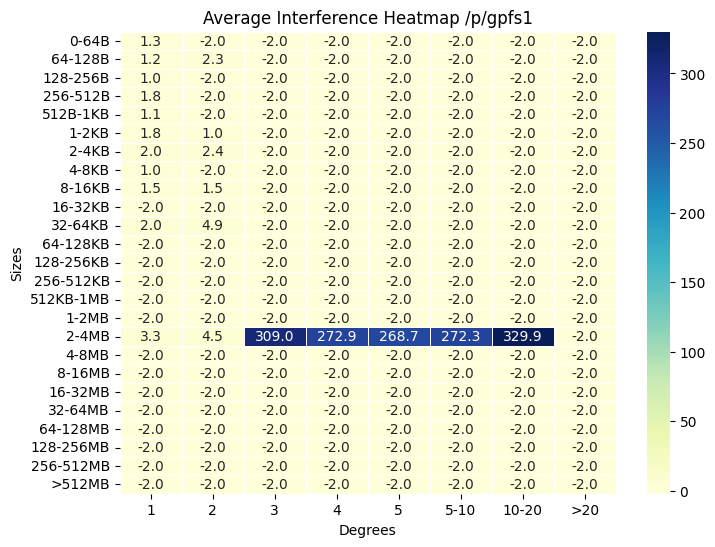

In [22]:
plot.hmap(mp='/p/gpfs1', df= write_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

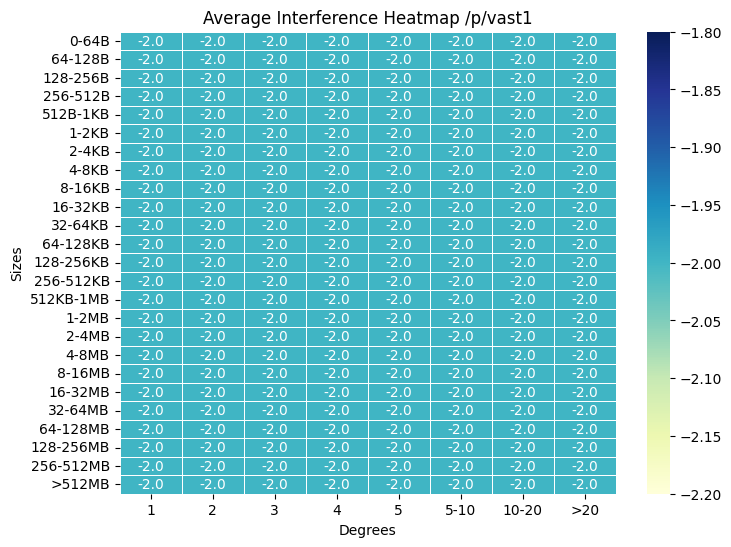

In [21]:
plot.hmap(mp='/p/vast1', df= write_df, size_bins=size_bins,size_labels= size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [10]:
# BASURA

In [16]:
events_obj.inter['delta_deg'] = events_obj.inter['deg_caller'] - events_obj.inter['deg_other']
events_obj.inter.head()



,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,delta_deg
0,write,0,134217728,660590087,660950423,/p/lustre2,360336,22,1,1,335032,0.929777,0
1,write,0,134217728,661006110,661369818,/p/lustre2,363708,22,1,1,335032,0.921157,0
2,write,0,134217728,661438391,661805701,/p/lustre2,367310,22,3,1,335032,0.912123,2
3,write,12,134217728,661725733,662300105,/p/lustre2,574372,22,9,1,335032,0.583301,8
4,write,15,134217728,661787472,662355067,/p/lustre2,567595,22,10,1,335032,0.590266,9


In [22]:
events_obj.inter.trange.unique().compute()

0     22
1     32
2     16
3     15
4      2
5     34
6     37
7     40
8     21
9     39
10    10
11    33
12    27
13     9
14    38
15     8
16    28
17    26
18     4
19    41
20    14
21    20
Name: trange, dtype: uint16[pyarrow]

In [24]:
len(events_obj.inter)

13596

In [23]:
a = events_obj.inter.query(f'trange == 41').compute()

In [24]:
a

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,delta_deg
0,read,8,1895,1234582801,1234582809,/,8,41,1,1,7,0.875,0
1,read,8,30827,1235081674,1235081720,/,46,41,1,1,34,0.73913,0
2,read,0,1895,1235538894,1235538901,/,7,41,1,1,7,1.0,0
3,read,0,30827,1235930980,1235931020,/,40,41,1,1,34,0.85,0
136,write,8,1895,1234582834,1234582837,/p/lustre2,3,41,1,1,3,1.0,0
137,write,8,30827,1235081739,1235082876,/p/lustre2,1137,41,1,1,772,0.67898,0
138,write,0,1895,1235538920,1235538923,/p/lustre2,3,41,1,1,3,1.0,0
139,write,0,30827,1235931040,1235932457,/p/lustre2,1417,41,1,1,772,0.544813,0
140,read,0,20,1252386333,1252388306,/p/lustre2,1973,41,1,1,3,0.001521,0
141,read,0,47,1252388317,1252388322,/p/lustre2,5,41,1,1,3,0.6,0


In [18]:
grouped.min()

np.float64(-1.2948670189070236e-15)

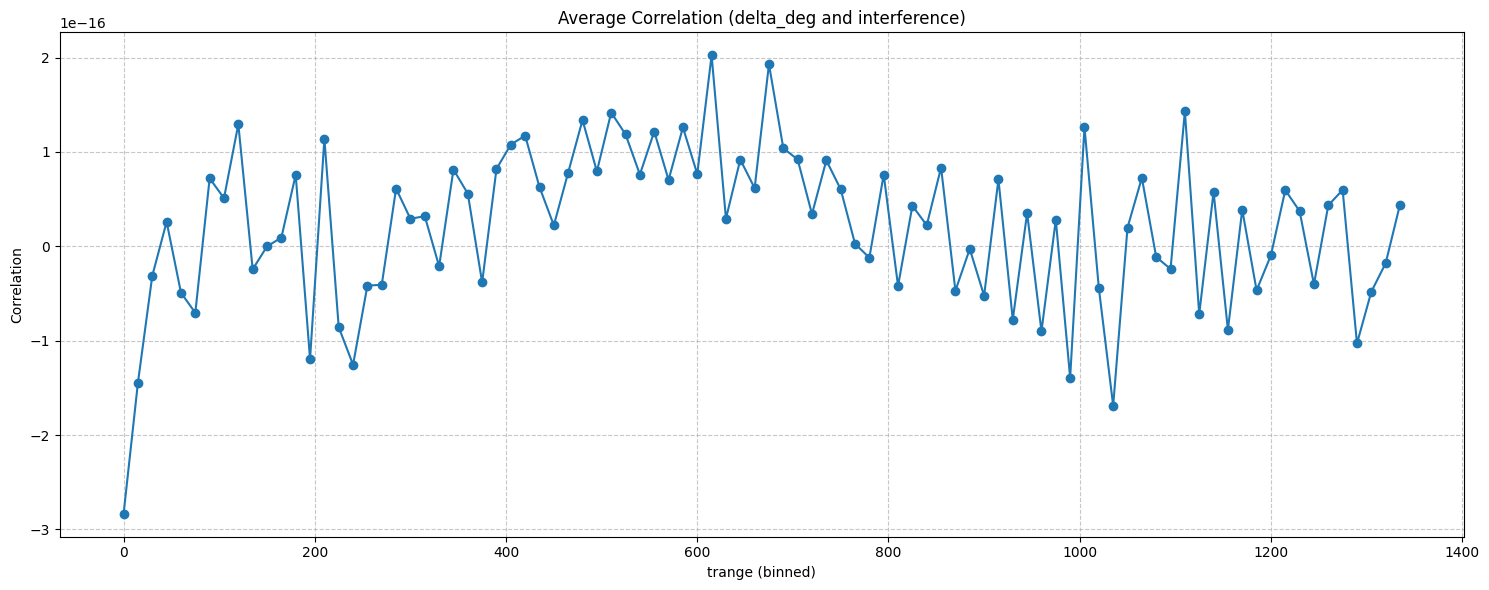

In [15]:
events_obj.inter['delta_deg'] = events_obj.inter.apply(lambda row : max(row['deg_other'] - row['deg_caller'], 0.1), axis = 1)
# max((events_obj.inter['deg_other'] - events_obj.inter['deg_caller']),0.1)
grouped = events_obj.inter.groupby('trange').apply(
    lambda x: x['delta_deg'].corr(x['interference']),
        meta=('correlation', 'f8')
    ).compute()
plot.correlation_plot(grouped=grouped, bin_size = 15, group_col ='trange', col_a = 'delta_deg', col_b = 'interference')

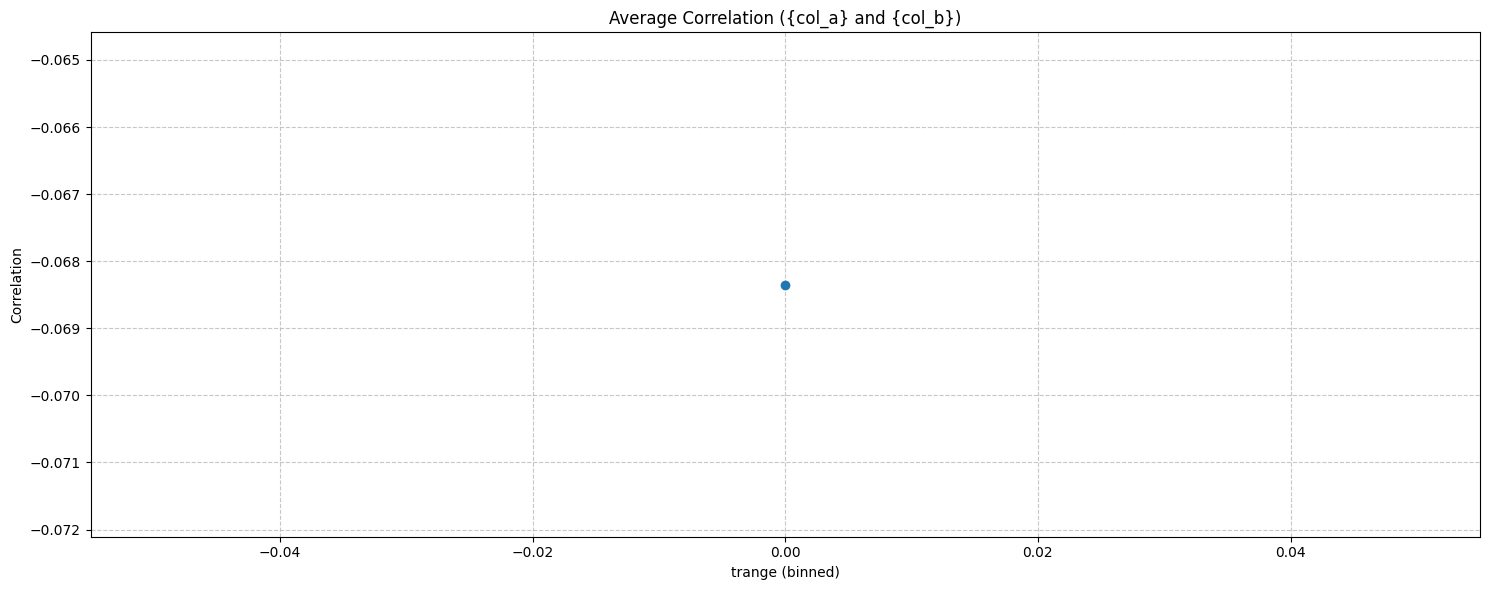

In [23]:
plot.correlation(events_obj.inter, group_col="trange", col_a="delta_deg", col_b= "interference")

In [30]:
size_bins = [
0,128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144
]
size_labels = [
'<128B','128B-256B','256B-512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB'
]
degree_bins = [
    0, 2, 3, 4, 5, 6, 10, 20, float('inf')
]
degree_labels = [
    '1', '2', '3', '4', '5', '5-10', '10-20', '>20',
]

In [11]:
grouped = ddf.groupby(group_col).apply(
lambda x: x[col_a].corr(x[col_b]),
    meta=('correlation', 'f8')
).compute()

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference
0,M1T0I0,3,64,10,60,/p/gpfs1,50,0,2,2,50,1.000000
1,M1T0I1,3,64,40,90,/p/gpfs1,50,0,2,2,50,1.000000
2,M1T1I0,2,128,110,190,/p/gpfs1,80,1,4,4,80,1.000000
3,M1T1I1,3,64,140,185,/p/gpfs1,45,1,3,2,50,1.111111
4,M1T1I2,2,32,160,180,/p/gpfs1,20,1,3,1,5,0.250000
5,M1T1I3,1,32,189,198,/p/gpfs1,4,1,2,1,5,1.250000
6,M0T2I0,1,64,210,250,/p/vast1,40,2,2,2,40,1.000000
7,M0T2I1,2,32,230,240,/p/vast1,10,2,2,2,10,1.000000
0,M1T2I0,1,32,220,225,/p/gpfs1,5,2,1,1,5,1.000000
1,M0T0I0,1,64,10,70,/p/vast1,60,0,2,2,40,0.666667


/usr/WS1/pandey2/DFtracer1/dftracer/dfanalyzer/graph_visualization/plots.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()


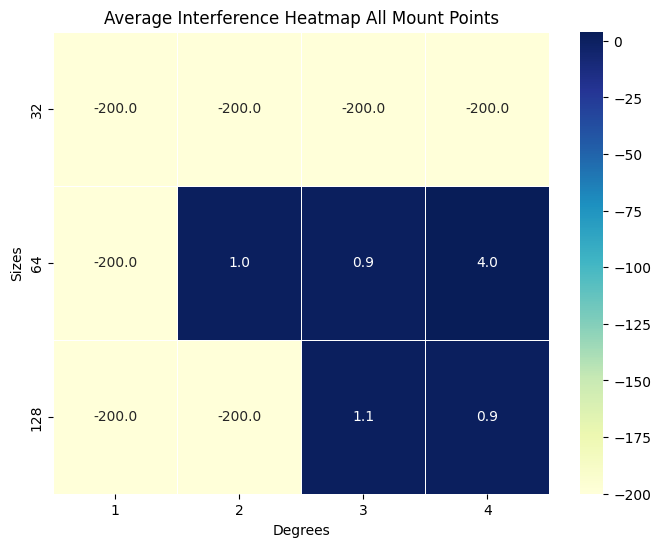

In [13]:
#def hmap(self, mp=None, df=None, size_bins=[], size_labels=[], degree_bins=[], degree_labels = []):
p.hmap(df=a.compute(),size_bins=size_bins, size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [12]:
def hmap(mp=None):
    df= inter.compute()
    if mp:
      df= df[df['mount_point']==mp]
    else:
       mp = "All Mount Points"
    size_bins, size_labels, degree_bins, degree_labels = binned_category()
    df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
    df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)

    df['interference'] = df['interference'].astype(float)

    all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
    merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
    grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()

    pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='interference').fillna(-0.005)
    # Create heatmap using seaborn
    plt.figure(figsize=(8, 6))
    pivot_table = 1/pivot_table
    sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
    plt.title(f'Average Interference Heatmap {mp}')
    plt.xlabel('Degrees')
    plt.ylabel('Sizes')
    plt.show()

In [84]:
df=inter.compute()
df.mount_point.unique()

<ArrowStringArray>
['/p/lustre1', '/tmp', '/', '/dev', '/sys']
Length: 5, dtype: string

/var/tmp/pandey2/ipykernel_1769341/3705242239.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()


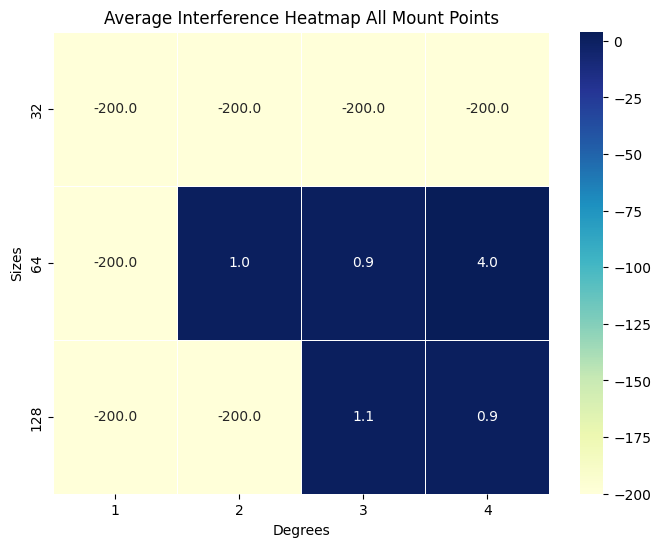

In [15]:
hmap()

/var/tmp/pandey2/ipykernel_3773976/2182960081.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()


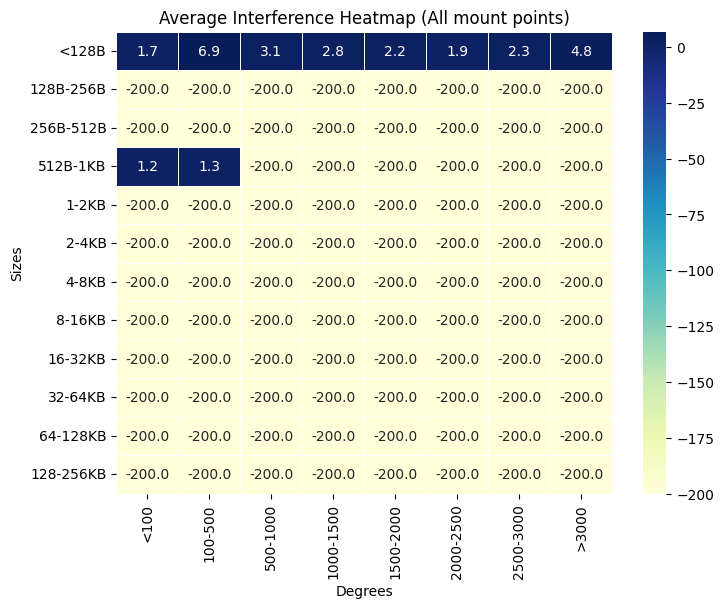

In [67]:
df= inter.compute()
df= df[df['mount_point']=='/sys']
size_bins, size_labels, degree_bins, degree_labels = binned_category()
df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)

df['interference'] = df['interference'].astype(float)

all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()

pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='interference').fillna(-0.005)
# Create heatmap using seaborn
plt.figure(figsize=(8, 6))
pivot_table = 1/pivot_table
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
plt.title('Average Interference Heatmap (All mount points)')
plt.xlabel('Degrees')
plt.ylabel('Sizes')
plt.show()

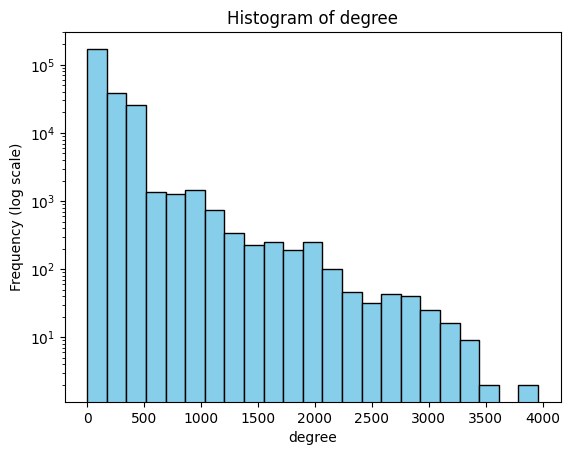

In [59]:
histogram(df['deg_caller'], "degree")

In [55]:
df=inter.compute()
print(df['deg_caller'].min())

1


In [3]:
gdata = {"nodes": [{"data": {"id": "1"}}, {"data": {"id": "2"}}, {"data": {"id": "4"}}, {"data": {"id": "3"}}], "edges": [{"data": {"source": "1", "target": "2"}}, {"data": {"source": "1", "target": "4"}}, {"data": {"source": "2", "target": "3"}}, {"data": {"source": "4", "target": "3"}}]}
app_view = ipycytoscape.CytoscapeWidget()
app_view.graph.add_graph_from_json(gdata)
# graph_view.set_layout(name="circle")
# app_view.set_layout(name="concentric")
# graph_view.set_layout(name="cola")
app_view.set_style(get_style('normal'))
app_view

CytoscapeWidget(cytoscape_layout={'name': 'cola'}, cytoscape_style=[{'selector': 'nodes', 'style': {'font-fami…

In [46]:
df.mount_point.unique()

<ArrowStringArray>
['/p/lustre1', '/tmp', '/', '/dev', '/sys']
Length: 5, dtype: string

/var/tmp/pandey2/ipykernel_3773976/4169560247.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()


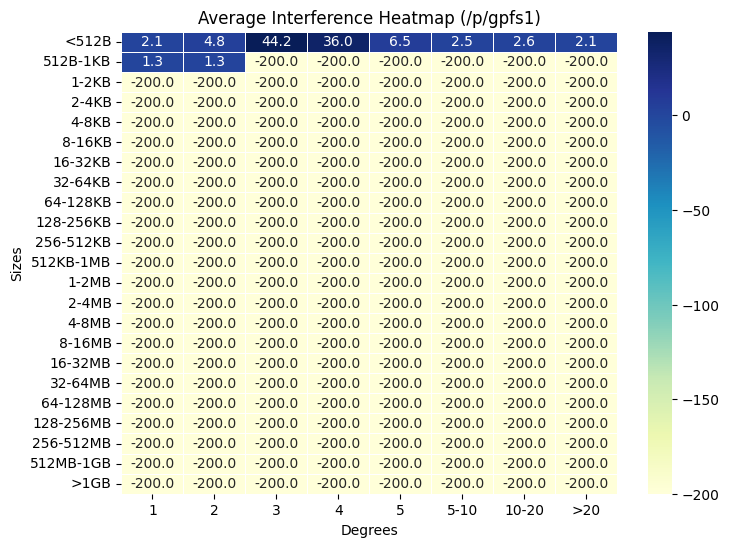

In [60]:
df=inter.compute()
df = df[df['mount_point']=="/sys"]
df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)

df['interference'] = df['interference'].astype(float)
# Create all combinations of Category1 and Category2
all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()
# Fill missing values with 0
pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='interference').fillna(-0.005)
# Create heatmap using seaborn
plt.figure(figsize=(8, 6))
pivot_table = 1/pivot_table
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
plt.title('Average Interference Heatmap (/p/gpfs1)')
plt.xlabel('Degrees')
plt.ylabel('Sizes')
plt.show()

/var/tmp/pandey2/ipykernel_3773976/2993915516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()


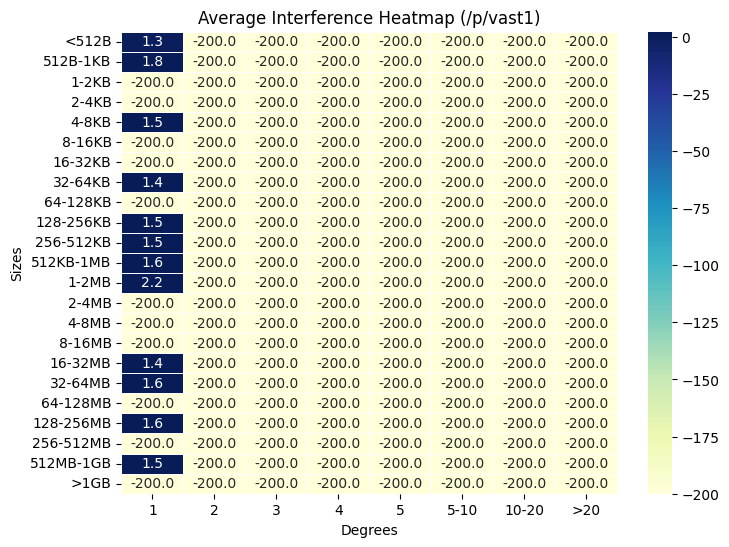

In [36]:
df=inter.compute()
df = df[df['mount_point']=="/p/vast1"]
df['size_category'] = pd.cut(df['size'], bins=size_bins, labels=size_labels, right=False)
df['deg_category'] = pd.cut(df['deg_caller'], bins=degree_bins, labels=degree_labels, right=False)

df['interference'] = df['interference'].astype(float)
# Create all combinations of Category1 and Category2
all_combinations = pd.MultiIndex.from_product([df['size_category'].unique(), df['deg_category'].unique()], names=['size_category', 'deg_category'])
merged = pd.merge(df, pd.DataFrame(index=all_combinations).reset_index(), on=['size_category', 'deg_category'], how='left')
grouped = merged.groupby(['size_category', 'deg_category']).agg({'interference': 'mean'}).reset_index()
# Fill missing values with 0
pivot_table = grouped.pivot(index='size_category', columns='deg_category', values='interference').fillna(-0.005)
# Create heatmap using seaborn
plt.figure(figsize=(8, 6))
pivot_table = 1/pivot_table
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5)
plt.title('Average Interference Heatmap (/p/vast1)')
plt.xlabel('Degrees')
plt.ylabel('Sizes')
plt.show()

In [41]:
df=inter.compute()
df.query('deg_caller > 20')['size'].max()

8638

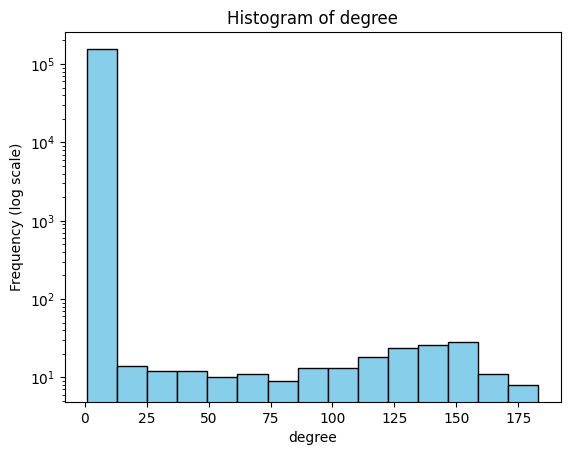

In [7]:
histogram(inter['deg_caller'], "degree")

In [13]:
inter["size"].unique().compute()

0       33854
1        8192
2        1752
3       33843
4        1075
        ...  
1731     2047
1732     5001
1733     5278
1734     8773
1735     8789
Name: size, Length: 1736, dtype: uint64[pyarrow]

In [45]:
inter.size.compute()

np.int64(1875048)

In [27]:
i = inter[inter['size']<1e8]

In [31]:

# Define size bins and labels for a wider range of bytes
size_bins = [
    0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
    1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
    268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
    '<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
    '64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
    '8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]
i = inter.compute()
i['size_category'] = pd.cut(i['size'], bins=size_bins, labels=size_labels, right=False)

In [43]:
i.size

2031302

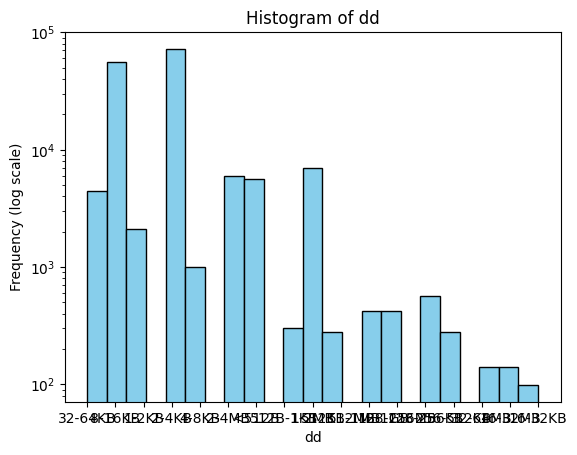

In [33]:
histogram(i['size_category'],"dd")

In [37]:
groups = i.groupby(['size','deg_caller'])['interference'].mean().reset_index()

In [40]:
groups

,size,deg_caller,interference
0,1,1,0.635034
1,1,2,0.625
2,22,1,0.695091
3,22,2,0.4
4,42,1,0.772479
...,...,...,...
2138,617099444,6,0.492486
2139,617099444,7,0.520571
2140,617099444,10,0.612211
2141,617099444,16,0.531832


In [41]:
groups.unstack()

size          0              1
              1              1
              2             22
              3             22
              4             42
                        ...   
interference  2138    0.492486
              2139    0.520571
              2140    0.612211
              2141    0.531832
              2142    0.531858
Length: 6429, dtype: object

In [30]:
# Build co-occurrence matrix and set diagonal to zero.
ct = pd.crosstab(df['deg_caller'], df['size'])
co_occurrence = ct.T.dot(ct)
np.fill_diagonal(co_occurrence.to_numpy(), 0)

f, ax = plt.subplots(figsize=(4, 5))

# Mask lower triangular for plotting.
mask = np.tril(np.ones_like(co_occurrence))

cmap = sns.light_palette("seagreen", as_cmap=True)
sns.heatmap(co_occurrence, mask=mask, cmap=cmap, square=True, cbar_kws={"shrink": .65})
plt.show()

np.int64(1)

/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/dataframe/core.py:3930: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting uint64[pyarrow] to object dtype.
  warnings.warn(
/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/dataframe/core.py:3930: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting uint64[pyarrow] to object dtype.
  warnings.warn(


TypeError: can only concatenate str (not "int") to str

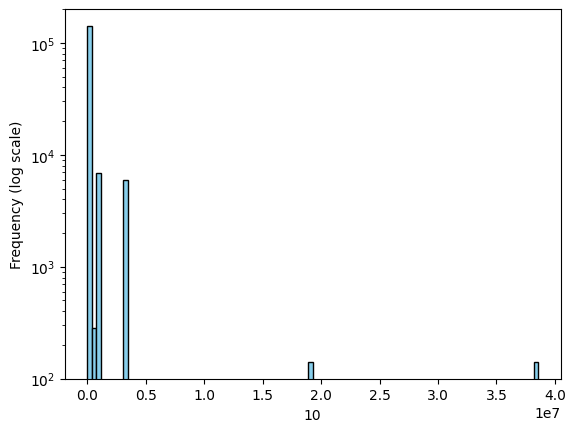

In [28]:
histogram(i['size'], )

In [20]:
inter["size"].max().compute()

np.int64(617099444)

In [18]:
i1 = inter[inter['size']<1024].size.compute()

In [17]:
i2 a= inter[inter['size']<2048].size.compute()

np.int64(96852)

In [3]:

use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    # 1 with open(f'/g/g91/pandey2/.dlio_profiler/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

# 2
# import dlp_analyzer
# print(dlp_analyzer.__file__)
# from dlp_analyzer.main import DLPAnalyzer,get_dlp_configuration,update_dlp_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dlp_configuration

# import dlp analyzer
import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration


# 3 Local Use
# if not use_local:
#     dask_run_dir = os.path.join(app_root, "dlp_analyzer", "dask", "run_dir")
#     with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
#         dask_scheduler = json.load(f)["address"]
# else:
#     dask_scheduler = None

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
app_name = "mummi" # resnet cosmoflow unet3d mummi deepspeed dlio_resnet dlio_cosmoflow

def get_conditions_cosmoflow(json_object):
    app_io_cond = "TFReader.parse_image" in json_object["name"] # Cosmoflow
    compute_cond = "compute" in json_object["name"] # Cosmoflow
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_resnet(json_object):
    app_io_cond = "IO" == json_object["cat"] # Resnet50
    compute_cond = "cpu" in json_object["name"] or "compute" in json_object["cat"] # Resnet50
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_unet3d(json_object):
    app_io_cond = "NPZReader.read_index" in json_object["name"] # Unet3d
    compute_cond = "compute" in json_object["name"] # Unet3d
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_dlio_resnet(json_object):
    app_io_cond = "read_index" in json_object["name"] # Unet3d
    compute_cond = "compute" in json_object["name"] # Unet3d
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond


condition_fn = None #

if app_name == "mummi":
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"

elif app_name == "deepspeed":
    filename = "/usr/workspace/iopp/dlp_traces/deepspeed_8_4ppn/*.pfw.gz"

elif app_name == "cosmoflow":#empty traces do not run yet
    filename = "/usr/WS2/iopp/kogiou1/dlio_benchmark/hydra_log/cosmoflow/2023-10-31-10-27-24/.trace*.pfw.gz"
    condition_fn = get_conditions_cosmoflow

elif app_name == "node32":#empty traces do not run yet
    filename = "/usr/workspace/iopp/dlp_traces/node_32_ppn_4/.trace*.pfw.gz"

elif app_name == "resnet":
    filename = "/usr/workspace/iopp/dlp_traces/resnet_50_1node_4ppn/*.pfw.gz"
    condition_fn = get_conditions_dlio_resnet




# if app_name == "cosmoflow":
#     filename = "/usr/WS2/iopp/kogiou1/dlio_benchmark/hydra_log/cosmoflow/2023-10-31-10-27-24/.trace*.pfw.gz"
#     condition_fn = get_conditions_cosmoflow
# elif app_name == "dlio_cosmoflow":
#     filename = "/usr/workspace/iopp/kogiou1/dlio_benchmark/hydra_log/cosmoflow/2023-11-01-18-47-58/.trace*.pfw.gz"
#     condition_fn = get_conditions_cosmoflow
# elif app_name == "resnet":
#     filename = "/usr/workspace/iopp/dlio_paper_results/resnet_50_1node_4ppn/*.pfw.gz"
#     condition_fn = get_conditions_resnet
# elif app_name == "unet3d":
#     filename = "/usr/workspace/iopp/kogiou1/dlio_benchmark_logs/unet3d/node_32_ppn_4/.trace*.pfw.gz"
#     condition_fn = get_conditions_unet3d
# elif app_name == "mummi":
#     filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/trace*.pfw.gz"
# elif app_name == "deepspeed":
#     filename = "/usr/workspace/iopp/dlp_traces/deepspeed_8_4ppn/*.pfw.gz"
# elif app_name == "dlio_resnet":
#     filename = "/usr/workspace/iopp/kogiou1/dlio_benchmark/hydra_log/resnet50/2023-11-01-10-52-58/.trace*.pfw.gz"
#     condition_fn = get_conditions_dlio_resnet
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, 
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=False, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/__init__.py


[INFO] [14:49:46] Initialized Client with 0 workers and link http://134.9.71.27:8787/status [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:670]
[INFO] [14:49:46] Restarting all workers [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:662]


In [14]:
mummiDDf.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange'], dtype='object')

In [15]:
ddf_deg = mummiDDf.groupby('trange').apply(get_deg , meta=meta)

In [19]:
mummiDDf.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange'], dtype='object')

In [22]:
def rando(df):
    df['c'] = 5
    return df

mt = {
        'name': str,
        'pid': int,
        'size': int,
        'ts': int,
        'te': int,
        'mount_point': str,
        'dur': int,
        'trange': int,
        'c': int  # Add 'deg' column to the metadata
        }
x = mummiDDf.groupby('trange').apply(rando,meta=mt)
x.head()

name    pid  size         ts         te mount_point  dur  trange  \
trange                                                                          
7.0    472  write  44934  8731  228639867  228639994    /p/gpfs1  127     7.0   
       477  write  44934  8729  228641976  228642077    /p/gpfs1  101     7.0   
       482  write  44934  8722  228643930  228644026    /p/gpfs1   96     7.0   
       487  write  44934  8697  228645866  228645970    /p/gpfs1  104     7.0   
       492  write  44934  8734  228647817  228647915    /p/gpfs1   98     7.0   

            c  
trange         
7.0    472  5  
       477  5  
       482  5  
       487  5  
       492  5

In [23]:
print(len(x),len(mummiDDf))

156254 156254


In [16]:
ddf_deg.head()

name     pid   size         ts         te mount_point  dur  trange  \
trange                                                                          
7.0    0  write  104999  33854  210104368  210104471    /p/gpfs1  103     7.0   
       1   read  104999   8192  211147581  211147595    /p/gpfs1   14     7.0   
       2   read  104999   8192  211147723  211147734    /p/gpfs1   11     7.0   
       3   read  104999   8192  211147819  211147828    /p/gpfs1    9     7.0   
       4   read  104999   1752  211147911  211147919    /p/gpfs1    8     7.0   

          deg  
trange         
7.0    0    1  
       1    1  
       2    1  
       3    1  
       4    1

In [12]:
dft1,agg_dict,len_deg = dur_of_min_deg(ddf_deg)
inter = calculate_interference(dft1,agg_dict=agg_dict,list_deg=len_deg)
#inter1 = calculate_interference_join(dft1, agg_dict=agg_dict, list_deg=len_deg)

In [13]:
inter.to_parquet('/p/lustre2/pandey2/Intermediatefiles/mummi/if')

In [18]:
inter['interfered'] = (inter['interference'] < 0.5).astype(int)


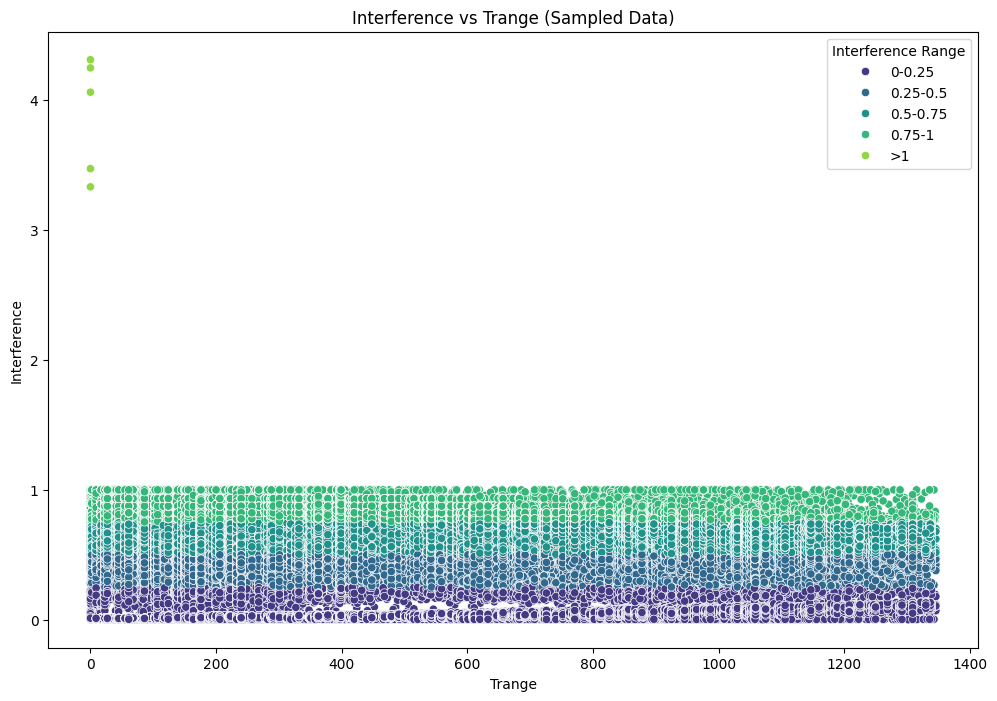

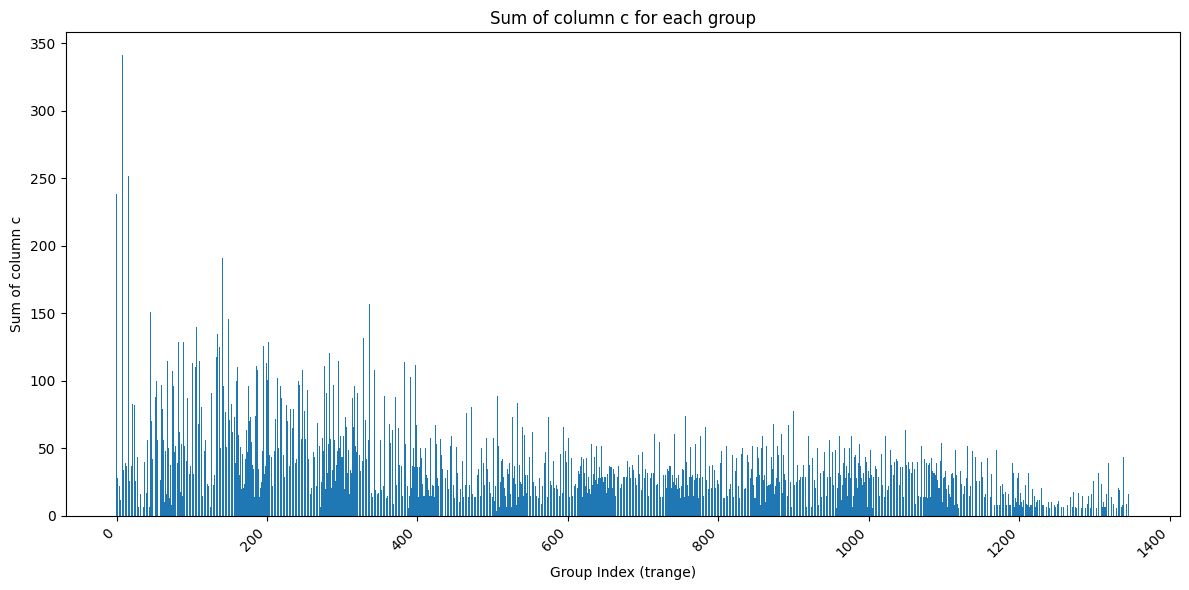

In [19]:
grouped = inter.groupby('trange')['interfered'].sum()
result = grouped.compute()

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(result.index, result.values)
plt.xlabel('Group Index (trange)')
plt.ylabel('Total count of interferred')
plt.title('Sum of column c for each group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

In [25]:
result.sort_values()

trange
56.0        0
80.0        0
57.0        0
1055.0      1
505.0       4
         ... 
141.0     191
23.0      236
0.0       238
16.0      252
8.0       341
Name: interfered, Length: 1287, dtype: int64

In [17]:
inter.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange',
       'deg_caller', 'deg_other', 'min_dur', 'interference'],
      dtype='object')

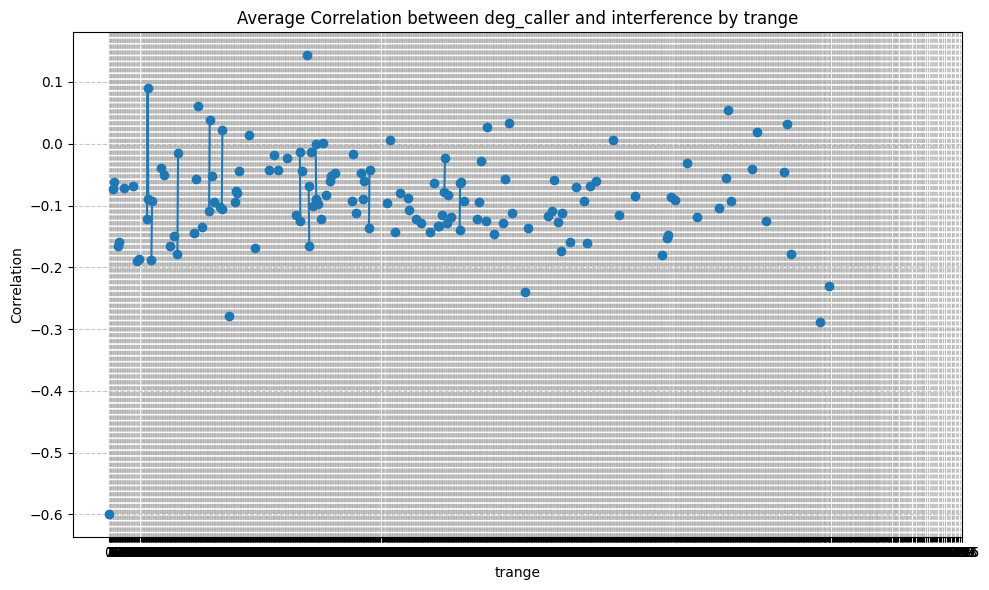

In [18]:
#scatter plot of the intereference, degree, correlation across trange
# Group by 'trange' and compute correlation

grouped = inter.groupby('trange').apply(
    lambda x: x['deg_caller'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()

# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()

# Visualize the results with a line plot
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o')
plt.title('Average Correlation between deg_caller and interference by trange')
plt.xlabel('trange')
plt.ylabel('Correlation')
plt.xticks(grouped.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

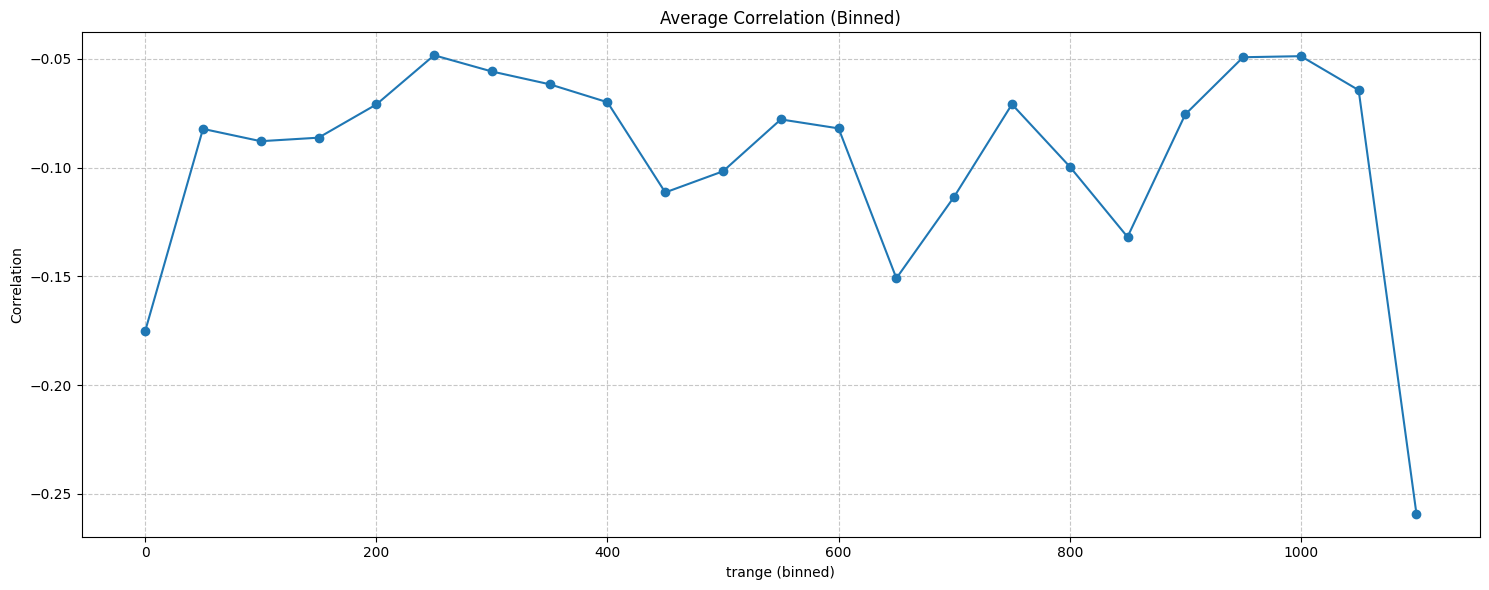

In [20]:
# 1. Binning the trange values
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()

plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('trange (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


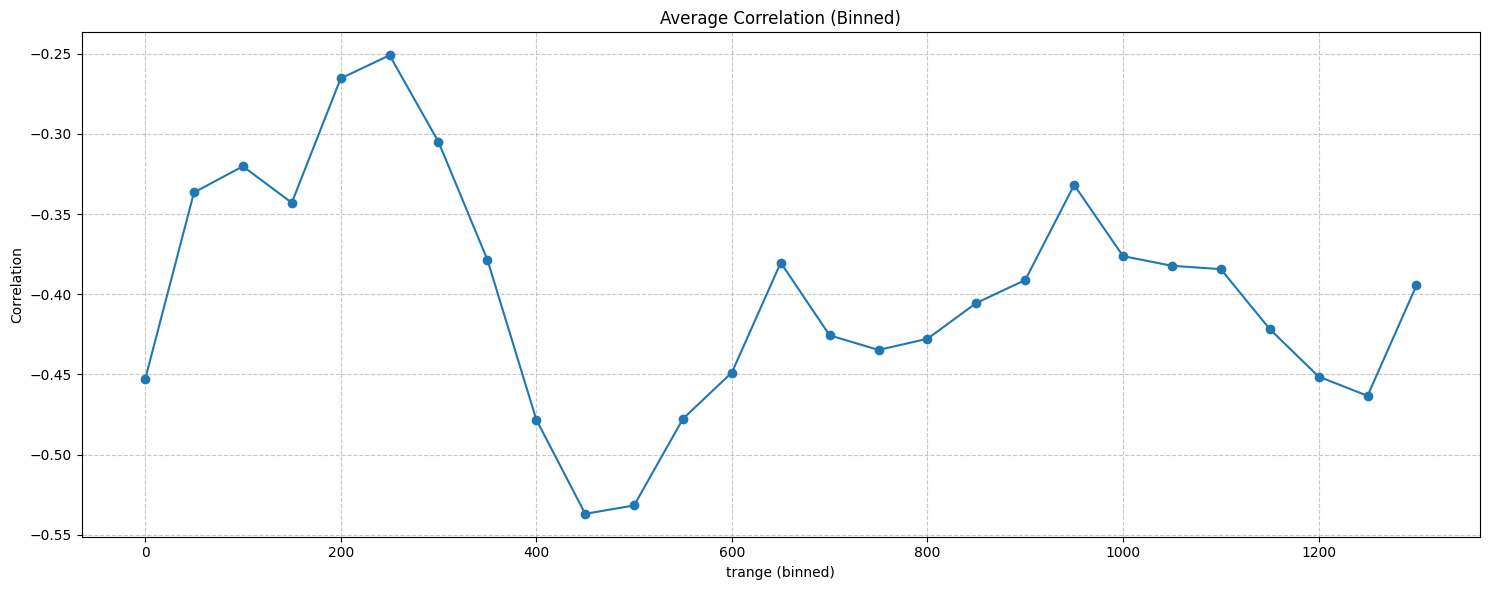

ValueError: cannot reshape array of size 1287 into shape (50)

<Figure size 2000x800 with 0 Axes>

In [21]:
grouped = inter.groupby('trange').apply(
    lambda x: x['dur'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()
# 1. Binning the trange values
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()

plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('trange (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




In [19]:
inter.columns

Index(['name', 'pid', 'size', 'ts', 'te', 'mount_point', 'dur', 'trange',
       'deg_caller', 'deg_other', 'min_dur', 'interference'],
      dtype='object')

In [24]:

grouped = inter.groupby(['size']).apply(
    lambda x: x['deg_caller'].corr(x['interference']),
    meta=('correlation', 'f8')
).compute()
# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()
bin_size = 50  # Adjust this value as needed
grouped_binned = grouped.groupby(grouped.index // bin_size).mean()
plt.figure(figsize=(15, 6))
plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
plt.title('Average Correlation (Binned)')
plt.xlabel('Size (binned)')
plt.ylabel('Correlation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


TypeError: cannot perform __floordiv__ with this index type: MultiIndex

In [25]:
grouped.head()

trange  size  mount_point
0.0     22.0  /p/vast1      NaN
        42.0  /p/vast1      NaN
        58.0  /p/gpfs1      NaN
        76.0  /p/gpfs1      NaN
        98.0  /p/vast1      NaN
Name: correlation, dtype: float64

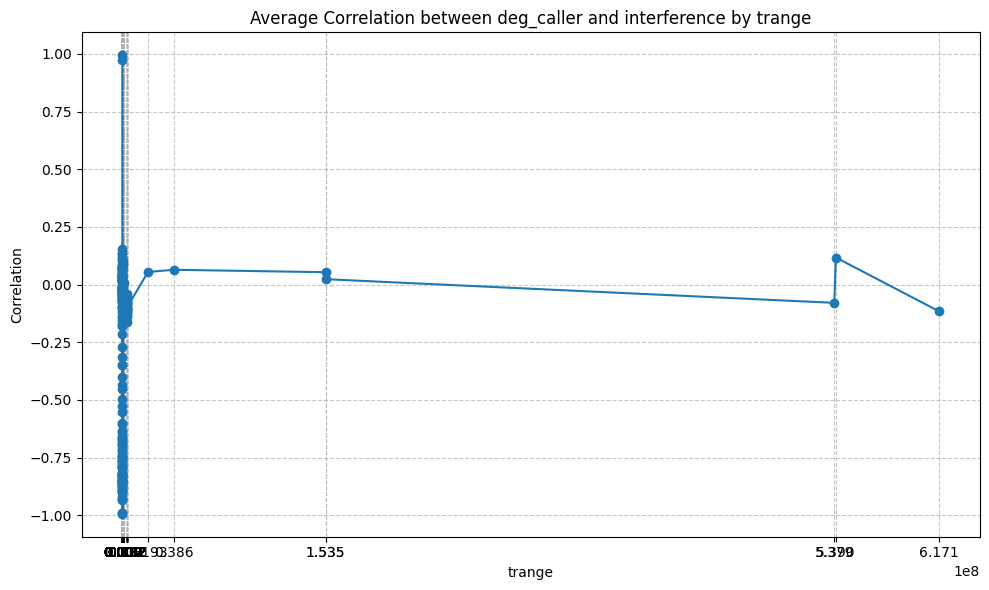

In [22]:
# bin_size = 500  # Adjust this value as needed
# grouped_binned = grouped.groupby(grouped.index // bin_size).mean()
# plt.figure(figsize=(15, 6))
# plt.plot(grouped_binned.index * bin_size, grouped_binned.values, marker='o')
# plt.title('Average Correlation (Binned)')
# plt.xlabel('Size (binned)')
# plt.ylabel('Correlation')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# Sort the index to ensure the line plot is in order
grouped = grouped.sort_index()

# Visualize the results with a line plot
plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o')
plt.title('Average Correlation between deg_caller and interference by trange')
plt.xlabel('trange')
plt.ylabel('Correlation')
plt.xticks(grouped.index)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
ddf = inter
# Create bins for interference values
bins = [0, 0.25, 0.5, 0.75, 1, float('inf')]
labels = ['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1', '>1']
# Add a new column with binned interference values
ddf['interference_bin'] = ddf['interference'].map_partitions(
    lambda x: pd.cut(x, bins=bins, labels=labels, include_lowest=True)
)
# Compute the counts for each bin
counts = ddf['interference_bin'].value_counts().compute()
# Sample the data for plotting (adjust the fraction as needed)
# sample_df = ddf.sample(frac=0.1).compute()
# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=ddf.compute(), x='trange', y='interference', hue='interference_bin', palette='viridis')
plt.title('Interference vs Trange (Sampled Data)')
plt.xlabel('Trange')
plt.ylabel('Interference')
plt.legend(title='Interference Range')
plt.show()

size   mount_point
60.0   /p/gpfs1      NaN
67.0   /p/gpfs1      NaN
362.0  /p/gpfs1      NaN
390.0  /p/gpfs1      NaN
526.0  /p/gpfs1      NaN
Name: correlation, dtype: float64

In [38]:
def get_edgelist(df):
    edge_list = []
    df = df.sort_values(by='ts').reset_index()
    group_length = len(df)
    for row in range(group_length):
        current_stop_time = df.loc[row,'te']
        for neigh in range(row+1, group_length):
            neigh_start_time = df.loc[neigh,'ts']
            if (neigh_start_time < current_stop_time):
                edge_list.append((row,neigh))
            else:
                break
    return edge_list



In [39]:

temp = get_edgelist(mummiDDf[mummiDDf['trange'] == 8])

ValueError: The truth value of a Series is ambiguous. Use a.any() or a.all().

In [31]:
temp

[]

In [ ]:
import pandas as pd
import numpy as np
import datetime

temp = pd.DataFrame({
    'pid' : [0] * 6,
    'mount_point' : ['alpha', 'beta'] * 3,
    'size' : [1]*6,
    'deg' : [np.random.randint(1,5) for i in range(6)],
    'dur' : [np.random.randint(1,100) for _ in range(6)],
})
tempddf = dd.from_pandas(temp,npartitions=1)
tempddf.compute()

In [ ]:
def dur_of_min_deg1(ddf):
    list_deg = ddf.groupby(["mount_point", "size"])["deg"].min().compute()
    agg_dict = {}
    for deg in list_deg:
        agg_dict[str(deg)] = min
        ddf[str(deg)] = 9223372036854775807
        ddf[str(deg)] = ddf[str(deg)].mask(ddf['deg'] == deg, ddf['dur'])
    return ddf,agg_dict,list_deg

def calculate_interference1(ddf, agg_dict, list_deg):
    agg_dict["deg"]= min
    val = ddf.groupby(['size','mount_point']).agg(agg_dict)
    val['min_dur']= 0
    for deg in list_deg:
        val['min_dur'] = val['min_dur'].mask(val['deg'].eq(deg),val[str(deg)])
    val = val.reset_index()[['name','pid','size', 'ts', 'te', 'mount_point', 'dur', 'trange','deg','min_dur']]
    val['tempIDX'] = val.map_partitions(lambda partition: partition.apply(lambda row: f"{row['size']}/{row['mount_point']}", axis=1), meta=('tempIDX', 'str'))
    # ddf2 = val.reset_index()[['size','mount_point','deg','min_dur']].set_index(['size','mount_point'])
    merge = ddf.join(val, on = ['tempIDX'], validate='m:1', lsuffix='_caller', rsuffix='_other')[['name','pid','size', 'ts', 'te', 'mount_point', 'dur', 'trange','deg','min_dur','deg_caller','deg_other']]
    merge['interference'] = merge['min_dur']/merge['dur']
    return merge

In [61]:
a,b = dur_of_min_deg(tempddf)
a.compute()

,pid,mount_point,size,deg,dur,2,1
0,0,alpha,1,3,76,9223372036854775807,9223372036854775807
1,0,beta,1,4,45,9223372036854775807,9223372036854775807
2,0,alpha,1,4,10,9223372036854775807,9223372036854775807
3,0,beta,1,3,10,9223372036854775807,9223372036854775807
4,0,alpha,1,2,60,60,9223372036854775807
5,0,beta,1,1,53,9223372036854775807,53


In [57]:
a,b = tem(tempddf)
a.compute()

,pid,mount_point,size,deg,dur,1,2
0,0,alpha,1,4,49,999,999
1,0,beta,1,3,74,999,999
2,0,alpha,1,1,32,32,999
3,0,beta,1,2,40,999,40
4,0,alpha,1,2,29,999,29
5,0,beta,1,3,67,999,999


In [63]:
mummiDDf.head()

,name,pid,tid,mount_point,dur,trange,tinterval,hostname,deg
7,read,38924,11634,/p/gpfs1,34394,0.0,"[149387,183781]",lassen429,1
34,write,38924,11634,/p/gpfs1,73,65.0,"[1961169995,1961170068]",lassen429,1
7,read,7935,11634,/p/gpfs1,37576,0.0,"[148545,186121]",lassen262,1
34,write,7935,11634,/p/gpfs1,68,63.0,"[1906224561,1906224629]",lassen262,1
7,read,172837,11634,/p/gpfs1,53939,0.0,"[246933,300872]",lassen278,1


In [ ]:
def dur_of_min_deg(dft):
    # Get the minimum degree for each group
    list_deg = dft.groupby(["mount_point", "size"])["deg"].min().compute()
    agg_dict = {}
    # Create new columns for each unique degree
    for deg in list_deg:
        deg_name = str(deg)
        dft[deg_name] = 9999
        agg_dict[deg_name] = min
        dft[deg_name] = dft.apply(
            lambda row: row["dur"] if row["deg"] == deg else 9999,
            axis=1,
            meta=(deg_name, 'int')
        )
    return dft,agg_dict